<a href="https://colab.research.google.com/github/mikikonomiya/olympic-data-analysis/blob/main/gender_parity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


--- SUMMER OLYMPICS ANALYSIS ---
[1] "Contingency Table:"
           
            Female  Male
  1900-1904     49  3188
  1906-1908     58  4776
  1912-1920    221  8111
  1924-1928    648  9577
  1932-1936    815  8660
  1948-1952   2125 12550
  1956-1960   2328 10918
  1964-1968   3125 13165
  1972-1976   4365 14580
  1980-1984   4203 12442
  1988-1992   7667 17347
  1996-2000  10439 17162
  2004-2008  11362 15683
  2012-2016  12038 14570

Chi-Squared Test Results:

	Pearson's Chi-squared test

data:  summer_table
X-squared = 21000, df = 13, p-value < 2.2e-16


--- WINTER OLYMPICS ANALYSIS ---
[1] "Contingency Table:"
           
            Female Male
  1924-1928     50  992
  1932-1936    103 1144
  1948-1952    318 1845
  1956-1960    541 1882
  1964-1968    820 2849
  1972-1976    849 2667
  1980-1984    966 2914
  1988-1992   1734 4341
  1994-1998   2489 4276
  2002-2006   3339 5152
  2010-2014   3870 5423

Chi-Squared Test Results:

	Pearson's Chi-squared test

data:  winter_

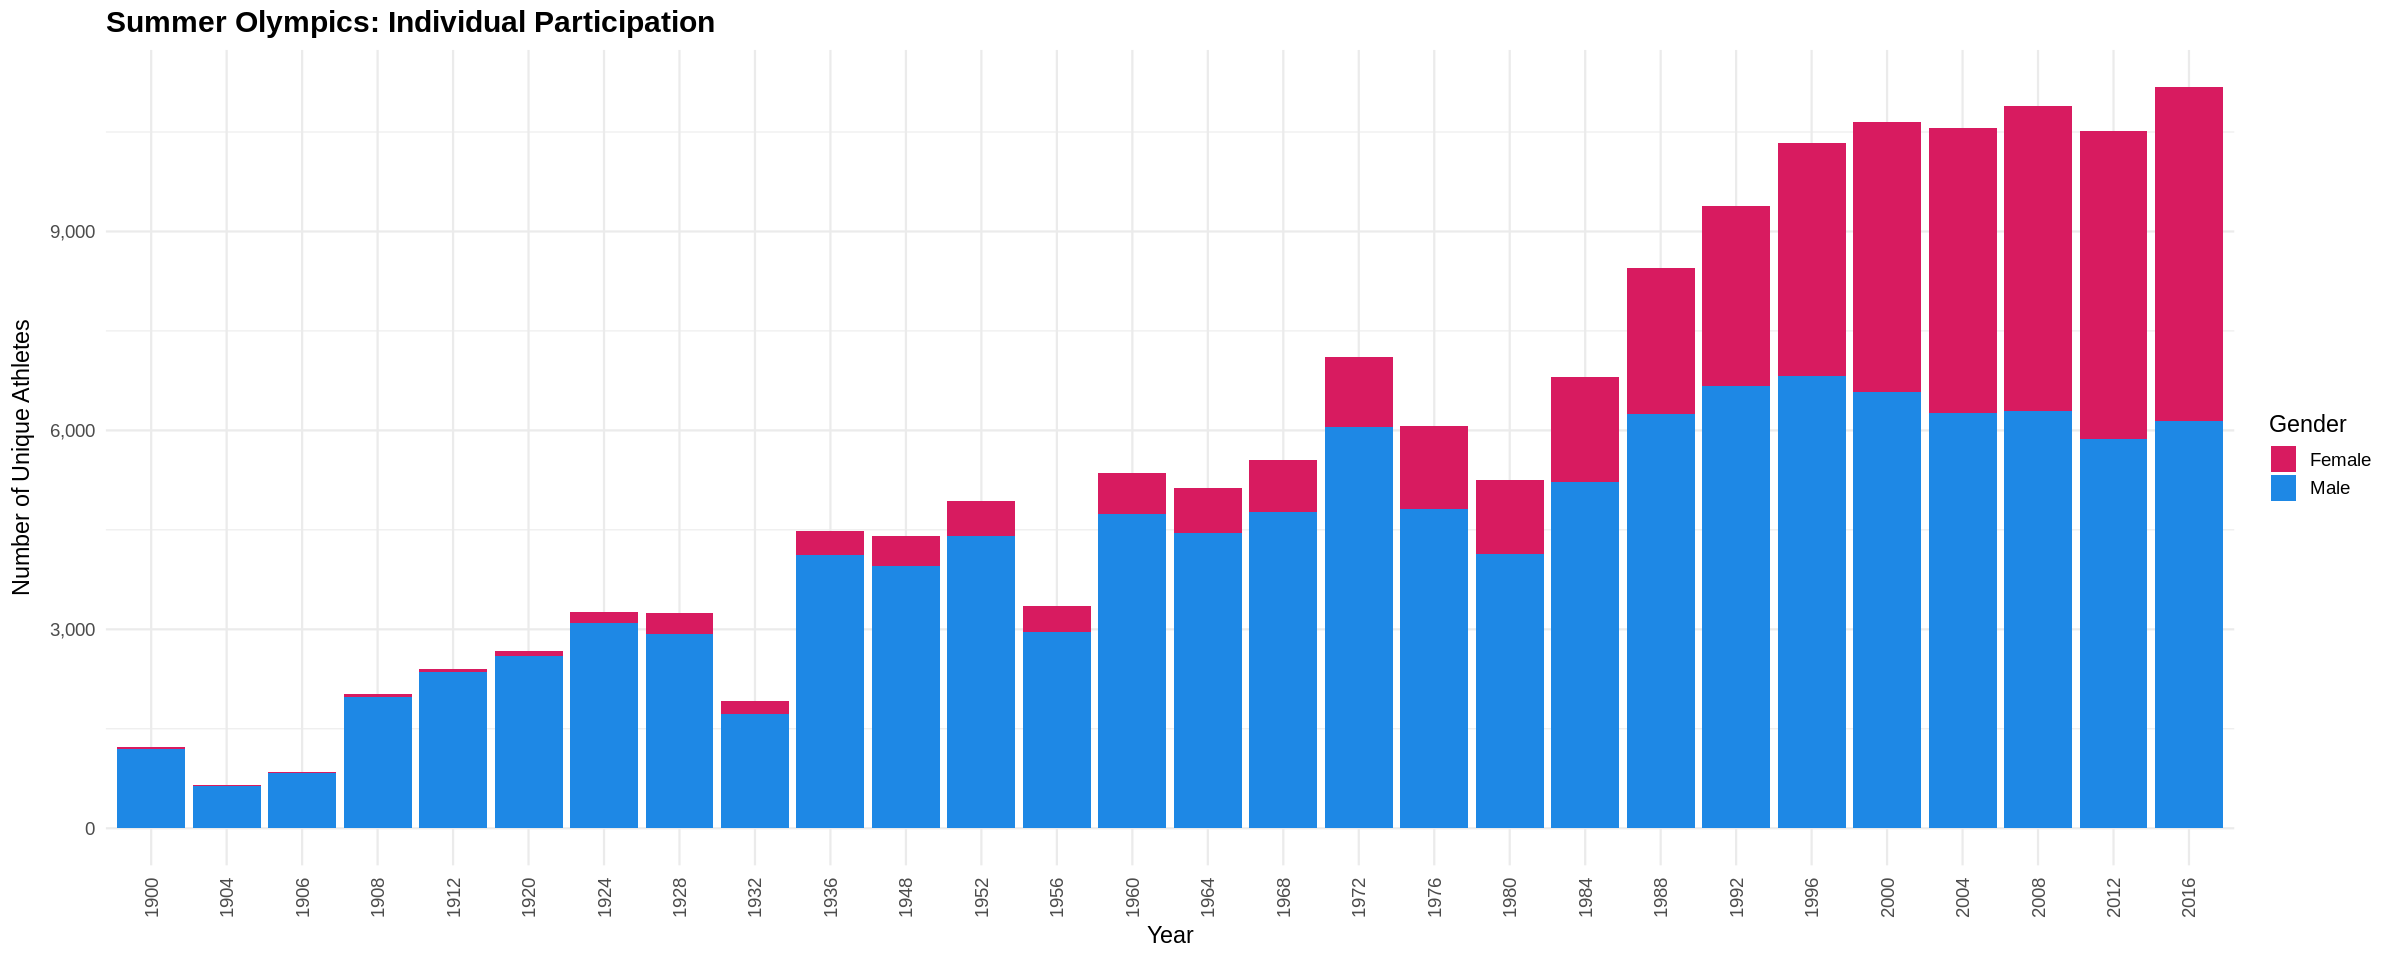

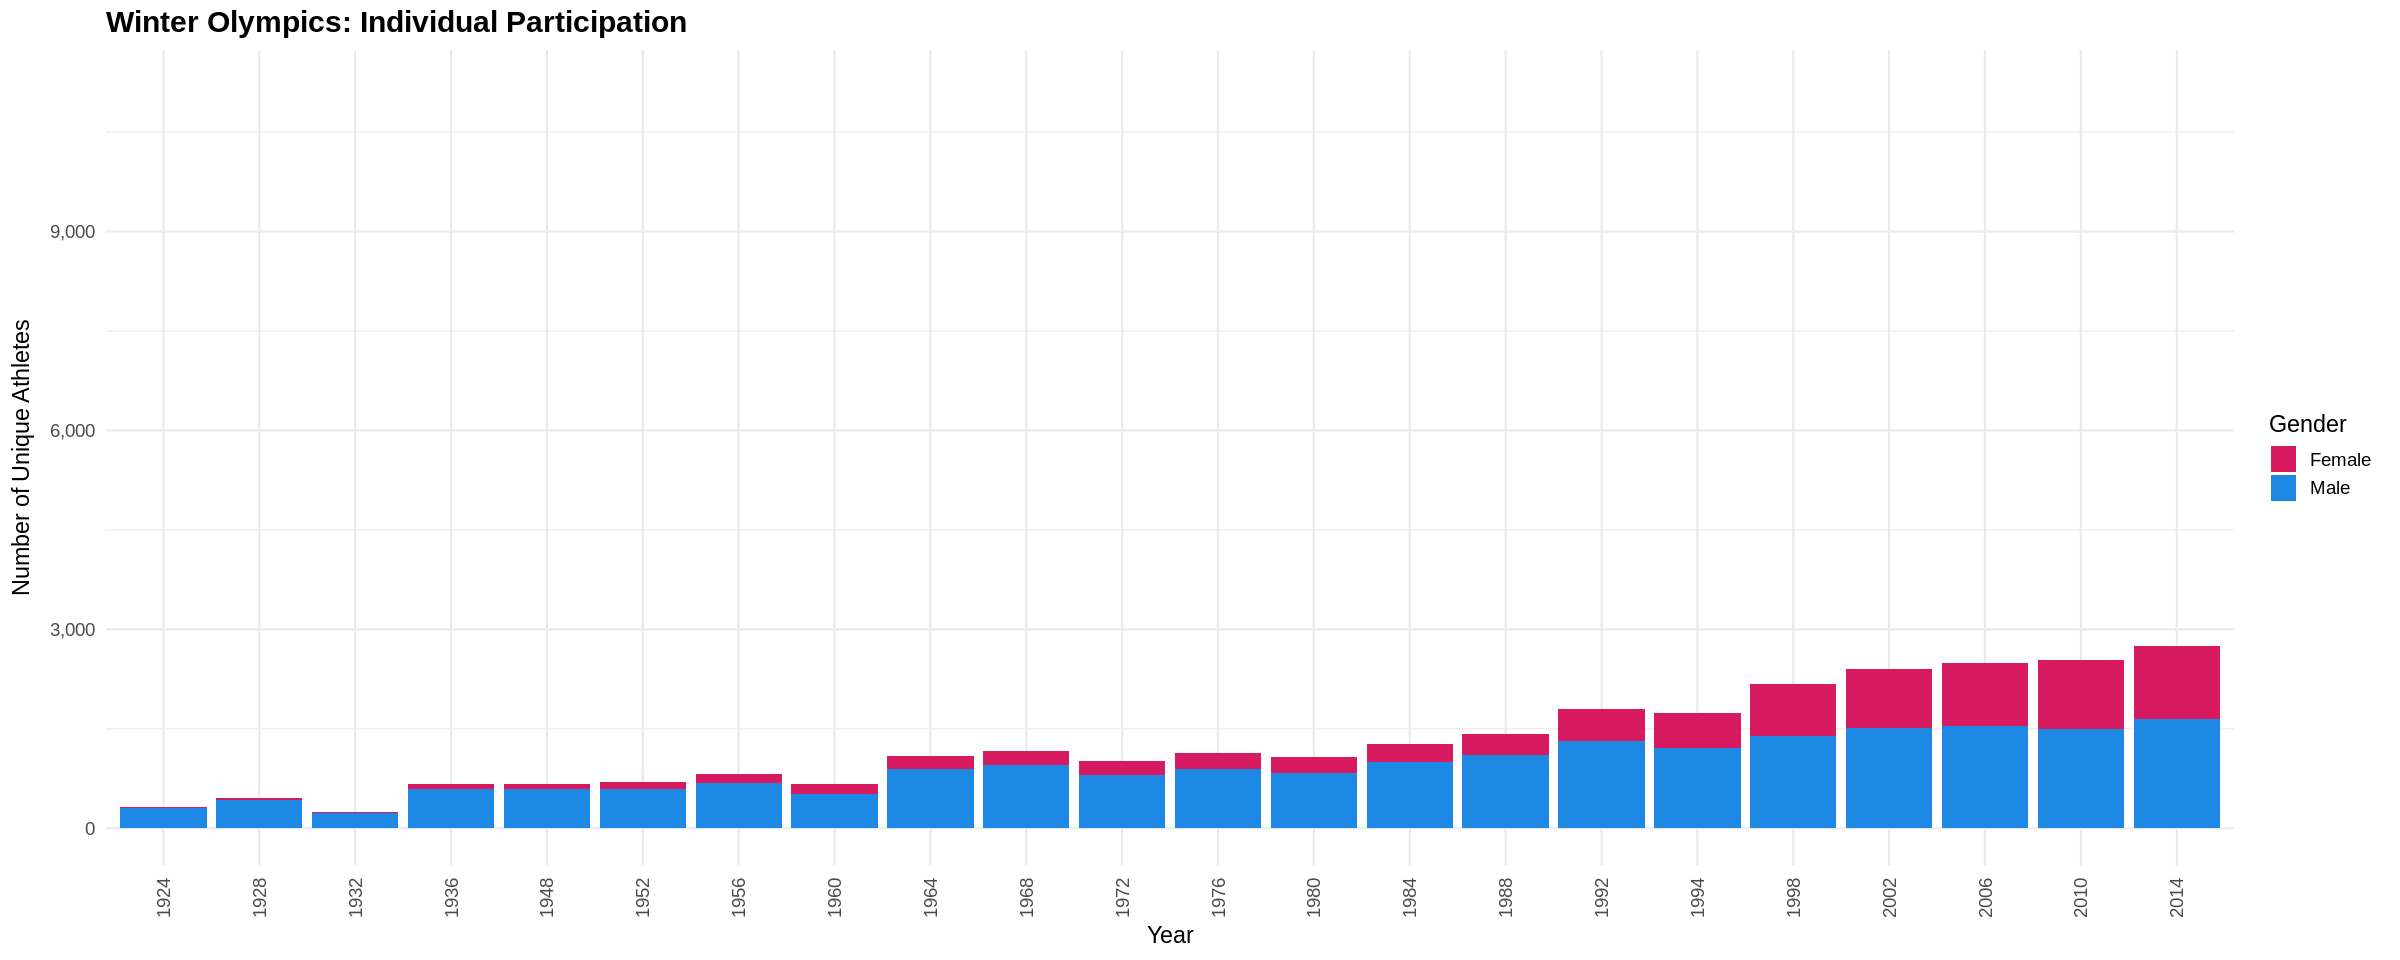

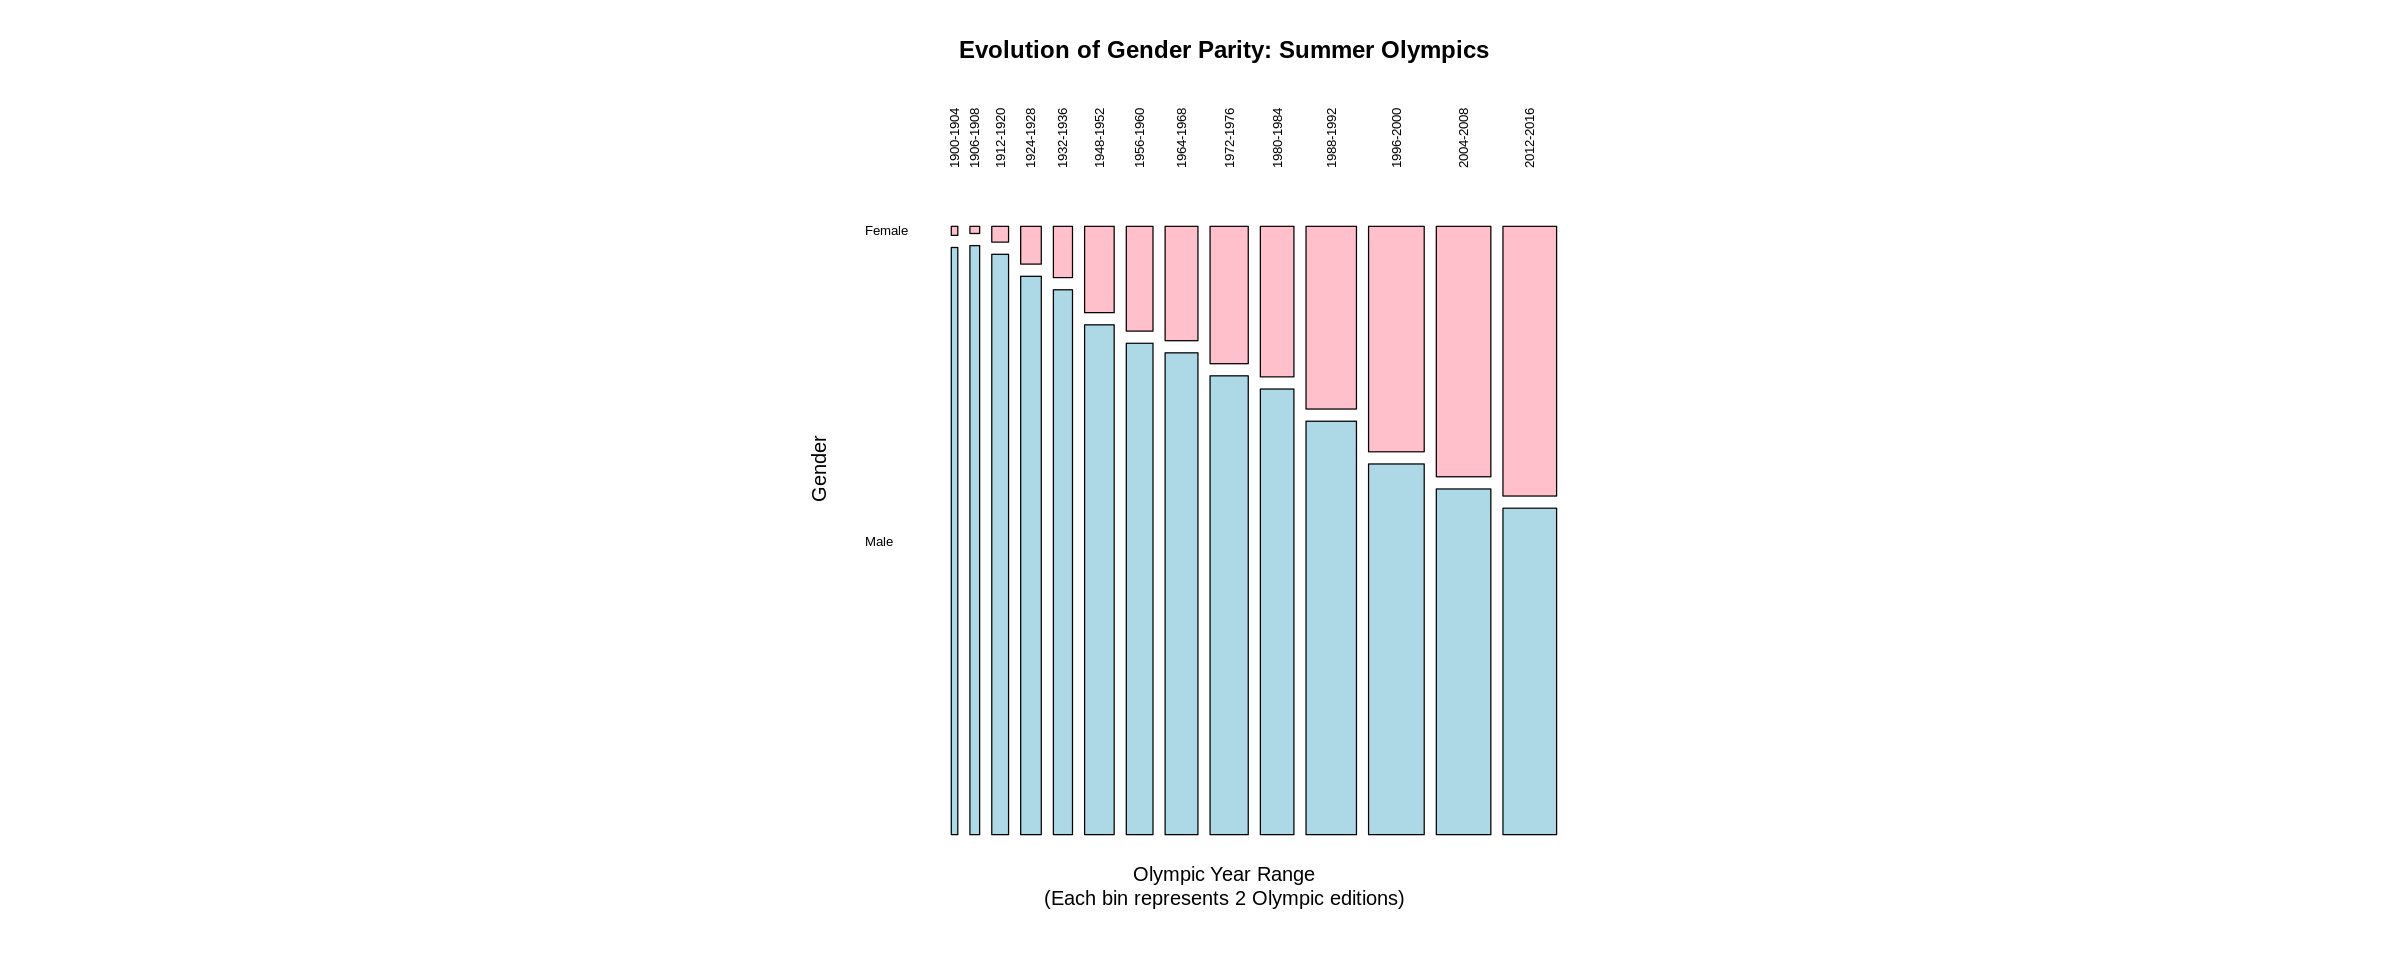

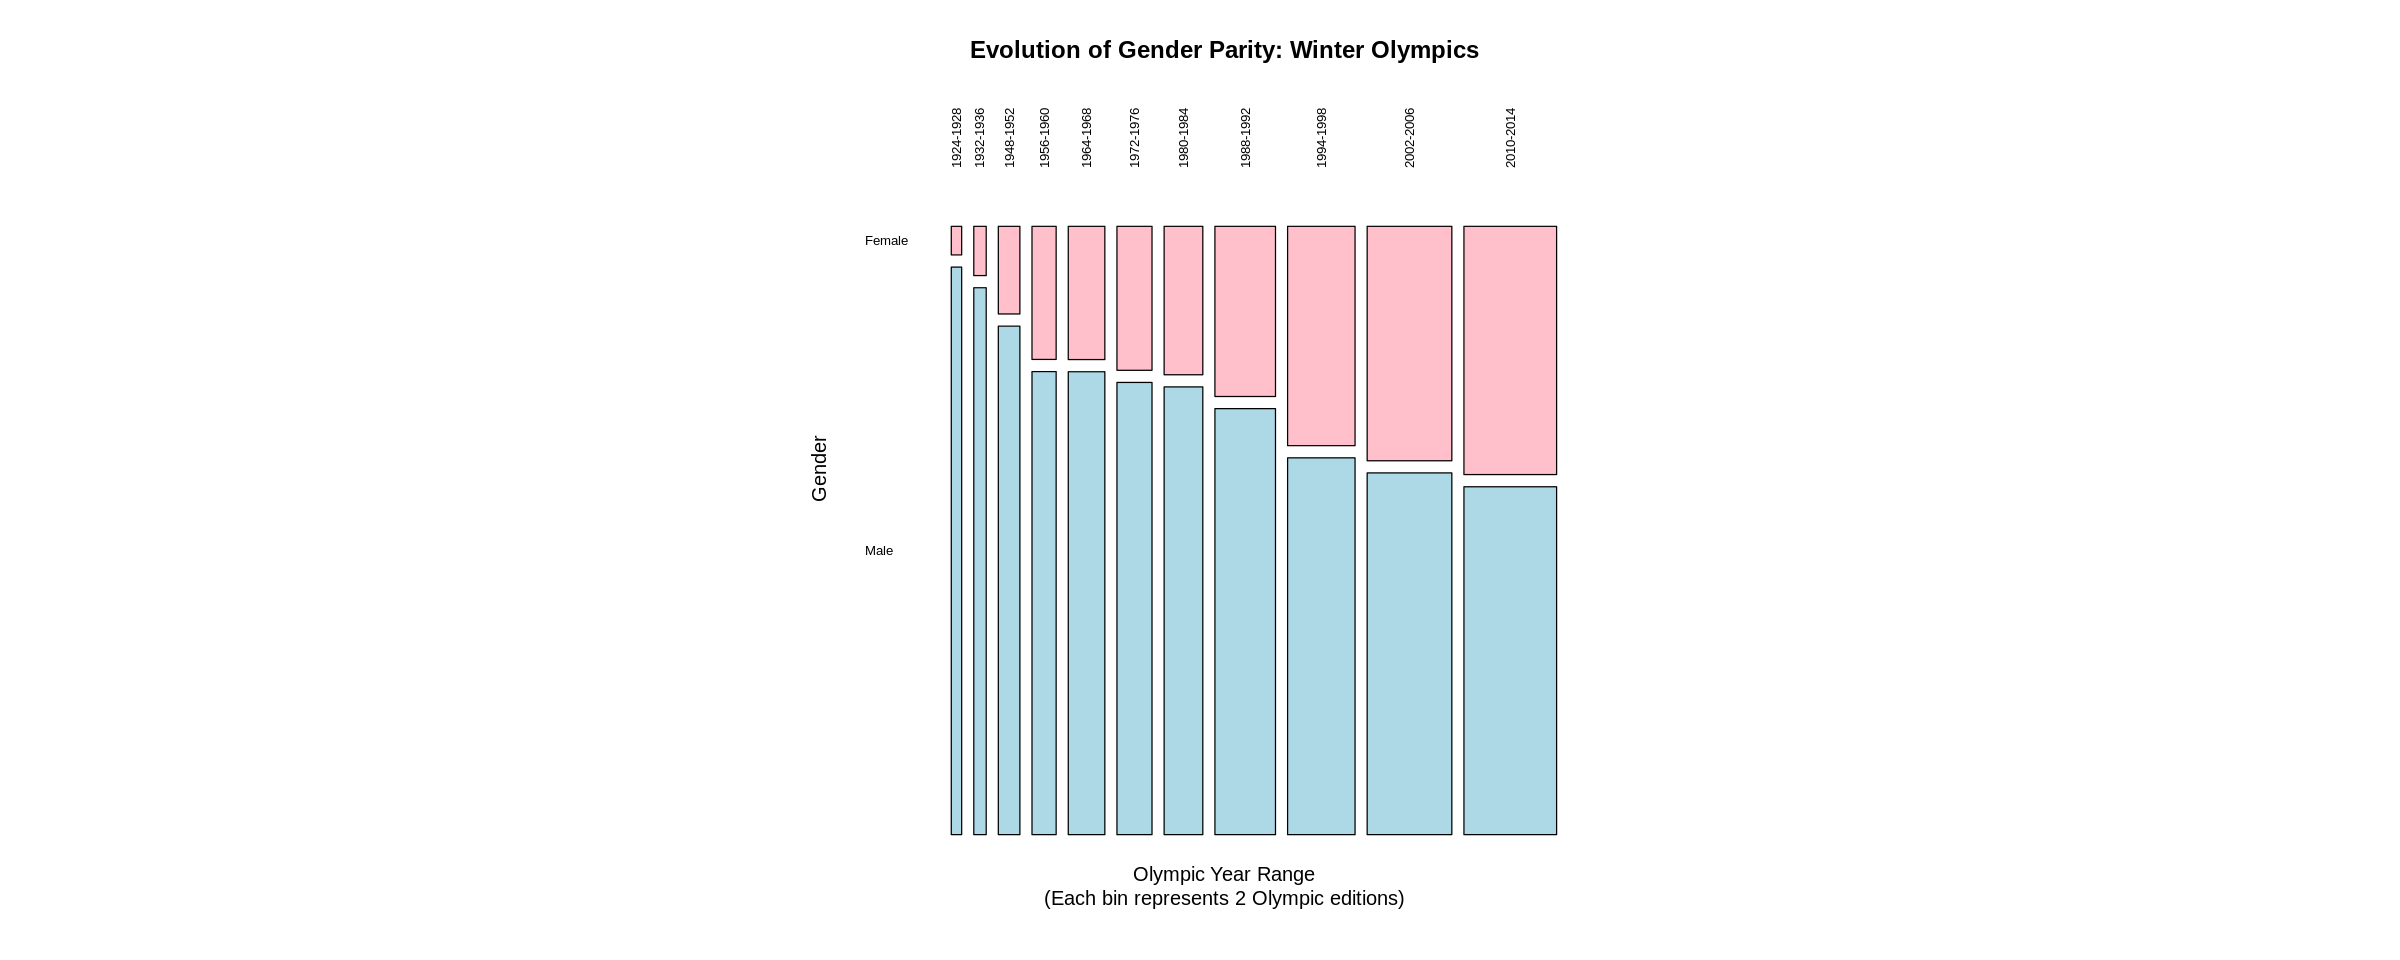

In [ ]:
# 1. LOAD LIBRARIES & DATA
library(tidyverse)
library(scales)

# Load once, filter for modern era, and clean sex labels
olympic_data <- read.csv("athlete_events.csv") %>%
  filter(Year >= 1900, !is.na(Sex)) %>%
  mutate(Sex = ifelse(Sex == "M", "Male", "Female"))

# 2. DATA PREPARATION FUNCTION
# This groups Olympics into blocks of 2 and creates the YearRange labels
prepare_olympic_data <- function(data, season_type) {
  years <- data %>%
    filter(Season == season_type) %>%
    distinct(Year) %>%
    arrange(Year) %>%
    mutate(OlympicGroup = floor((row_number() - 1) / 2) + 1)

  labels <- years %>%
    group_by(OlympicGroup) %>%
    summarise(YearRange = paste(min(Year), max(Year), sep = "-"), .groups = 'drop')

  data %>%
    filter(Season == season_type) %>%
    left_join(years %>% select(Year, OlympicGroup), by = "Year") %>%
    left_join(labels, by = "OlympicGroup")
}

df_summer <- prepare_olympic_data(olympic_data, "Summer")
df_winter <- prepare_olympic_data(olympic_data, "Winter")

# 3. STATISTICAL ANALYSIS (Tables & Chi-Squared)
summer_table <- table(df_summer$YearRange, df_summer$Sex)
winter_table <- table(df_winter$YearRange, df_winter$Sex)

cat("\n--- SUMMER OLYMPICS ANALYSIS ---\n")
print("Contingency Table:")
print(summer_table)
cat("\nChi-Squared Test Results:\n")
print(chisq.test(summer_table))

cat("\n--- WINTER OLYMPICS ANALYSIS ---\n")
print("Contingency Table:")
print(winter_table)
cat("\nChi-Squared Test Results:\n")
print(chisq.test(winter_table))

# 4. NORMALIZED STACKED BAR CHARTS
# Calculate the maximum Y value across both seasons for a consistent scale
max_y_summer <- df_summer %>% group_by(Year) %>% summarise(n = n_distinct(ID)) %>% pull(n) %>% max()
max_y_winter <- df_winter %>% group_by(Year) %>% summarise(n = n_distinct(ID)) %>% pull(n) %>% max()
global_max_y <- max(max_y_summer, max_y_winter)

options(repr.plot.width = 20, repr.plot.height = 8)
my_colors <- c("Female" = "#D81B60", "Male" = "#1E88E5")

plot_participation <- function(df, season_name) {
  df %>%
    group_by(Year, Sex) %>%
    summarise(Athlete_Count = n_distinct(ID), .groups = 'drop') %>%
    ggplot(aes(x = as.factor(Year), y = Athlete_Count, fill = Sex)) +
    geom_bar(stat = "identity", position = "stack") +
    scale_fill_manual(values = my_colors) +
    scale_y_continuous(limits = c(0, global_max_y), labels = comma) + # Normalization
    labs(title = paste(season_name, "Olympics: Individual Participation"),
         x = "Year", y = "Number of Unique Athletes", fill = "Gender") +
    theme_minimal(base_size = 14) +
    theme(axis.text.x = element_text(angle = 90, vjust = 0.5),
          plot.title = element_text(face = "bold", size = 18))
}

print(plot_participation(df_summer, "Summer"))
print(plot_participation(df_winter, "Winter"))

# 5. SQUARE MOSAIC PLOTS (Original Colors)
# Force square aspect ratio
par(pty = "s")

mosaicplot(summer_table,
           main = "Evolution of Gender Parity: Summer Olympics",
           sub = "(Each bin represents 2 Olympic editions)",
           xlab = "Olympic Year Range", ylab = "Gender",
           color = c("pink", "lightblue"), las = 2)

mosaicplot(winter_table,
           main = "Evolution of Gender Parity: Winter Olympics",
           sub = "(Each bin represents 2 Olympic editions)",
           xlab = "Olympic Year Range", ylab = "Gender",
           color = c("pink", "lightblue"), las = 2)

# Reset plot parameters
par(pty = "m")